# Heart Data Modelling and Analysis
*Heart dataset sourced from Kaggle: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci*

*Supplementary Kaggle dataset for comparison: https://www.kaggle.com/datasets/aavigan/cleveland-clinic-heart-disease-dataset*

*Raw data from UCI: https://archive.ics.uci.edu/dataset/45/heart+disease*

# The Data

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heart.csv')

First look at the data: 

In [3]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


Check how many examples and how many features are in the dataset

In [4]:
df.shape

(303, 14)

**There are 303 examples and 13 features plus the target**

*Let's review the features discription:*

age - age in years

sex - (1 = male; 0 = female)

cp - chest pain type

trestbps - resting blood pressure (in mm Hg on admission to the hospital)

chol - serum cholestoral in mg/dl

fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)

restecg - resting electrocardiographic results

thalach - maximum heart rate achieved

exang - exercise induced angina (1 = yes; 0 = no)

oldpeak - ST depression induced by exercise relative to rest

slope - the slope of the peak exercise ST segment

ca - number of major vessels (0-3) colored by flourosopy

thal - 1 = fixed defect; 2 = normal; 3 = reversable defect

target - have disease or not (1=yes, 0=no)

#  Data Cleaning and Preprocessing 

Check if all values are numeric

In [5]:
df.dtypes

All features are numeric, perfect.

Are there missing values? 

In [6]:
df.isna().sum()

**No missing Values!!**

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Few interesting insights: 

1. The average patient is 54.36 
2. 'ca' have values outside the range in the discription (4)
3. 'thal' have values outside the range in the discription (0)

In [8]:
df.thal.value_counts()

In [9]:
df.ca.value_counts()

It seems as there are 7 instances that are inconsistent with the discription. It could be wither typos or missing values that were imputed in this dataset with out of range values 

we will explore this futher later.. 

What is the label distribution? 

<AxesSubplot:ylabel='target'>

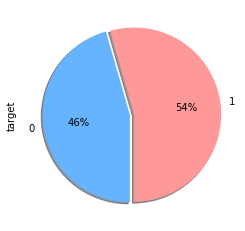

<Figure size 432x288 with 1 Axes>

In [ ]:
df.target.value_counts(normalize = True).plot.pie(autopct='%1.0f%%', startangle = 270,explode=[0.05,0], colors=['#ff9999','#66b3ff'], shadow=True)

Having more diseased patients than not. 

That seems a bit odd, but let's examine more...

Let's check some common premises regarding heart disease

First, we learn that "growing older increases your risk of damaged and narrowed arteries and a weakened or thickened heart muscle" (https://www.mayoclinic.org/diseases-conditions/heart-disease/symptoms-causes/syc-20353118) 

Is this can be seen in the data? 

<AxesSubplot:xlabel='age'>

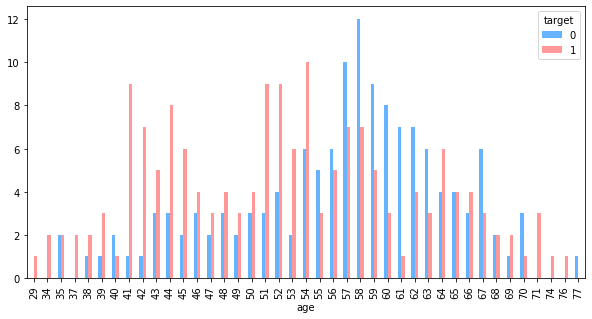

<Figure size 720x360 with 1 Axes>

In [ ]:
pd.crosstab(df.age,df.target).plot(kind="bar",figsize=(10,5), color=['#66b3ff', '#ff9999'])

Well.. not really

The histogram is inconsistent with the common knowledge,

in fact it tells the exact opposite. It seems that as you grow you become less exposed to heart disease. Super weird

We also know that "men are generally at greater risk of heart disease. The risk for women increases after menopause." (same source) 

Let's see

<AxesSubplot:xlabel='target', ylabel='age'>

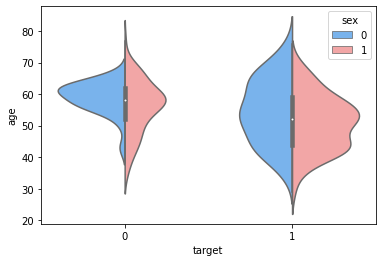

<Figure size 432x288 with 1 Axes>

In [ ]:
sns.violinplot(data=df,y='age', x='target', hue='sex', palette=['#66b3ff', '#ff9999'],  split=True)

This violin plot is also inconsistent with the common knowledge, in fact it tells once again the opposite.

Diseased patients, are seemed to be distributed fairly equally across ages both in males and females

While healthy men show a steady increase with age, and women seems to become dramatically healthier after age 50 

This is not right!! 

This makes us suspect that the target is mislabeled. 

we went online and located the original dataset from https://archive.ics.uci.edu/ml/datasets/heart+disease to see what is wrong with our data

In [13]:
df2 = pd.read_csv('processed.cleveland.csv')

In [14]:
df2.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2,3,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0,3,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1,7,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0,7,1


First, we see that some categorical values other than the target are different so we will need to make some adjusments. But we also see that the instances are shuffled!  

In [15]:
df2.dtypes

We see 2 features that are "object" type. The data values should be numerical

Interestingly enough, these are the two features we suspect of having typos/missing values

In [16]:
df2.ca.value_counts()

In [17]:
df2.thal.value_counts()

Indeed, those instances were missing in the original data. **We will remove those after we get to the bottom of this part**

We see that thal and ca have some missing values as the string: "?" For the sake of comparison, we will much those values to our dataset. 

In [18]:
df2.replace(to_replace={'thal': {"?": 0}, 'ca': {"?": 4}}, inplace=True)



**To compare the given dataset with the original UCI version, we align the values so that they match**

*We use the discription on the UCI website and some manual exploration of the data to "reverse engineer" the modifications that was done to data:*

In [19]:
df2.replace(to_replace={'target': {0: 0, 1: 1, 2: 1, 3: 1, 4: 1},
                        'thal': {"3":2, "6":1, "7":3}, 
                        'cp': {3:2,4:0,2:1,1:3}, 'slope': {1:2,2:1,3:0},
                        'restecg': {0:1,2:0,1:2}}, inplace=True)

We need to resort both datasets to validate that the instances are indeed the same, and make sure they appear in the same order for the comparison

In [20]:
df3 = df.sort_values(by=['chol'])
df4 = df2.sort_values(by=['chol'])

In [21]:
df3.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3,1
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
53,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
151,71,0,0,112,149,0,1,125,0,1.6,1,0,2,1
267,49,1,2,118,149,0,0,126,0,0.8,2,3,2,0


In [22]:
df4.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
202,57,1,2,150,126,1,1,173,0,0.2,2,1,3,0
300,57,1,0,130,131,0,1,115,1,1.2,1,1,3,1
93,44,0,2,108,141,0,1,175,0,0.6,1,0,2,0
273,71,0,0,112,149,0,1,125,0,1.6,1,0,2,0
232,49,1,2,118,149,0,0,126,0,0.8,2,3,2,1


In [23]:
df3 = df3.reset_index(drop=True)
df4 = df4.reset_index(drop=True)
df3.compare(df4)

age 
 sex 
 cp 
 trestbps 
 chol 
 ... 
 oldpeak 
 slope 
 ca 
 thal 
 target 
 
 
 
 self 
 other 
 self 
 other 
 self 
 other 
 self 
 other 
 self 
 other 
 ... 
 self 
 other 
 self 
 other 
 self 
 other 
 self 
 other 
 self 
 other 
 
 
 
 
 0 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 1.0 
 1 
 NaN 
 NaN 
 1.0 
 0.0 
 
 
 1 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 1.0 
 1 
 NaN 
 NaN 
 0.0 
 1.0 
 
 
 2 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 0.0 
 0 
 NaN 
 NaN 
 1.0 
 0.0 
 
 
 3 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 0.0 
 0 
 NaN 
 NaN 
 1.0 
 0.0 
 
 
 4 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 3.0 
 3 
 NaN 
 NaN 
 0.0 
 1.0 
 
 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 ... 
 
 
 298 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 0.0 
 0 
 NaN 
 NaN 
 1.0 
 0.0 
 
 
 299 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 3.0 
 3 
 NaN 
 NaN 
 0.0 
 1.0 
 
 
 300 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 2.0 
 2 
 NaN 
 NaN 
 0.0 
 1.0 
 
 
 301 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 1.0 
 1 
 NaN 
 NaN 
 1.0 
 0.0 
 
 
 302 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 ... 
 NaN 
 NaN 
 NaN 
 NaN 
 0.0 
 0 
 NaN 
 NaN 
 1.0 
 0.0 
 
 
 
 303 rows × 28 columns

As we suspected!! indeed, the target labels were switched



Let's try again... 

In [24]:
#correcting the data
df=df.replace(to_replace={'target': {0: 1, 1: 0}})

                          

Target: Has disease | No disease

(1=yes, 0=no)

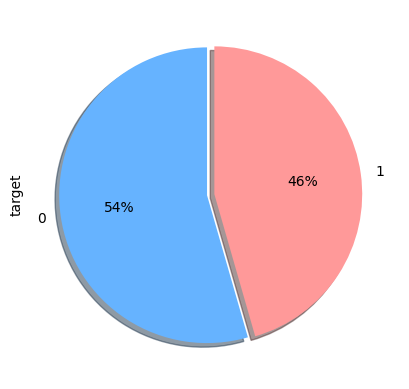

<AxesSubplot:ylabel='target'>

In [ ]:
df.target.value_counts(normalize = True).plot.pie(autopct='%1.0f%%',
                                                  startangle = 90,explode=[0.05,0], colors=['#66b3ff', '#ff9999'], shadow=True)

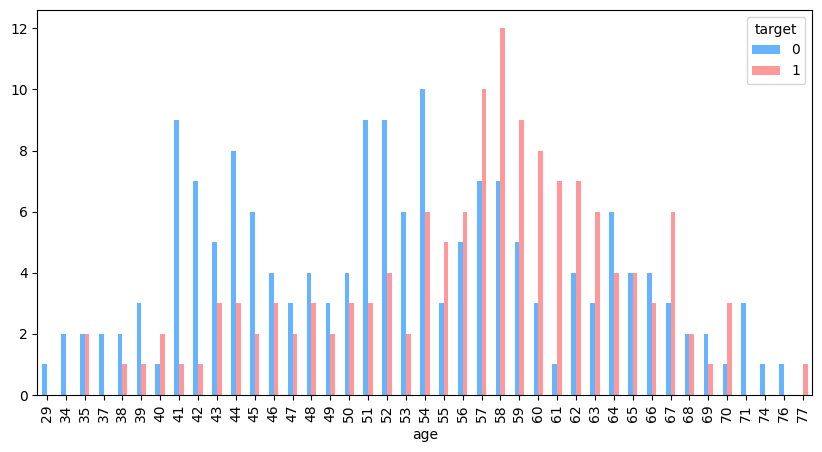

<AxesSubplot:xlabel='age'>

In [ ]:
pd.crosstab(df.age,df.target).plot(kind="bar",figsize=(10,5), color=['#66b3ff', '#ff9999'])

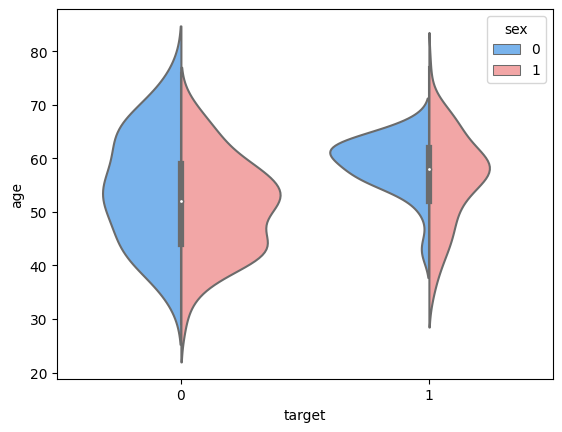

<AxesSubplot:xlabel='target', ylabel='age'>

In [ ]:
sns.violinplot(data=df,y='age', x='target', hue='sex', palette=['#66b3ff', '#ff9999'],  split=True)

Thankfuly, now we can indeed confirm the common premises with the data:

As you get older you are more likely to have heart issue 

And as a man you are at a greater risk overall while women close the gap after menopause

Let's keep going. What about other features?? 

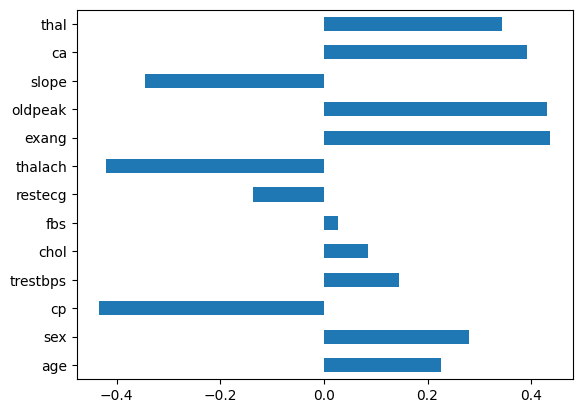

<AxesSubplot:>

In [ ]:
df.corr()['target'].drop('target').plot(kind='barh')

No significant linear correlation to the target

Fasting Blood Sugar and Cholesterol are very low

let's see why?

**ca correlation increased after dropping 5 elements that were marked as missing**

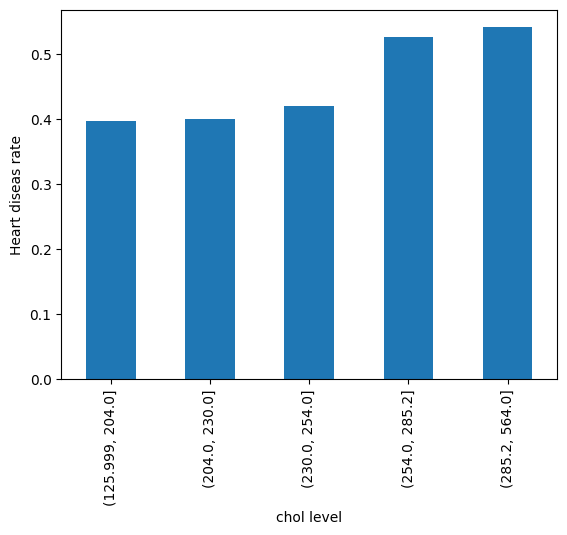

In [ ]:
number_of_bins = 5
df.groupby(pd.qcut(df.chol, number_of_bins)).target.mean().plot.bar()
plt.ylabel('Heart diseas rate')
plt.xlabel('chol level');

While we do see a trend here, i.e. as chol increases there are more diseased patients, it is very mild. the averages mostly revolve around the middle. 

We then search online to find out more, as it is commonly known that cholesterol is connected to heart diseases. 

We found that "total cholesterol, when considered alone, is a poor predictor of heart disease and heart attack. Studies show that total cholesterol levels among people who’ve had heart attacks are almost the same as those of people who haven’t, and that roughly half of heart attacks occur in people without high cholesterol.

If you have other risk factors for heart disease, particularly a family history, having your HDL and LDL particle size measured with an advanced blood test will give you a far clearer picture of your heart risk than the conventional lipid panel. Having a lot of large particles cuts your risk for a heart attack, while having a lot of small ones raises it. You do not want more than 15 percent of your particles to be the small, dense type."

**In other words, there is a good cholesterol and a bad one. measuring the sum of both is meaningless as you can have an healthy patient with high good cholesterol and low bad one with the exact same total as a sick patients who has high amount of bad and low amount of good**


https://www.everydayhealth.com/heart-health-pictures/the-single-best-predictor-of-a-heart-attack.aspx

Despite that we decide to keep this feature as it could have meaning together with other features. 

**______________________________________________________________**

Let's review fbs (fasting blood sugar)

We remind ourselves that this dataset treats fbs higher than 120 mg/dl as 1 while the rest is 0 fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)




In [30]:
fbs_distribution = df.fbs.value_counts(normalize=True).sort_index()
fbs_distribution

In [31]:
has_disease_by_fbs = df.groupby('fbs').target.mean()
has_disease_by_fbs

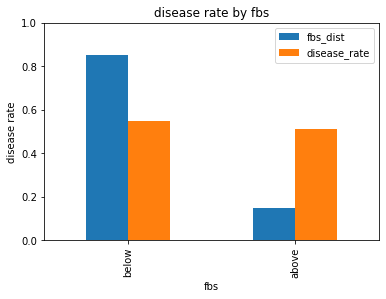

<Figure size 432x288 with 1 Axes>

In [ ]:
fbs_stats = pd.DataFrame({'fbs_dist':fbs_distribution, 'disease_rate':has_disease_by_fbs})
fbs_stats.index = fbs_stats.index.map({0:'below', 1:'above'})
fbs_stats.plot(kind='bar')
plt.xlabel('fbs')
plt.ylabel('disease rate')
plt.ylim(0, 1)
plt.title('disease rate by fbs');

"study shows a fasting BG of above 100 increases risk of heart disease by 300%. >People with a fasting blood sugar level of 100-125 mg/dl had an adjusted nearly 300% increase higher risk of having coronary heart disease than people with a level below 79 mg/dl. This information was compiled from a cross-sectional study of nearly 2500 people.

A fasting blood sugar level of more than 125 mg/dl is the current threshold for identifying patients with diabetes. But the new finding suggests that patients with high levels of blood sugar in the nondiabetic range face a substantial risk of coronary heart disease.


The Cleveland Clinic Foundation now uses a fasting blood sugar of 90 mg/dl or higher as a biomarker of coronary heart disease risk. The Cleveland Clinic gets very concerned when they someone with a fasting blood sugar above 90 mg/dl. They try to intervene with exercise, diet and weight control.

The previous cutoff of 125 mg/dl was based on the incidence of diabetic retinopathy, but physicians now increasingly focus on the diabetes-related risk of coronary heart disease. As evidence continues to grow in this area it is likely the definition of diabetes will change.


Normal fasting blood glucose is below 100 mg/dl. A person with pre-diabetes has a fasting blood glucose level between 110 and 125. If the level rises to 126 or above, a person has full-blown diabetes."

**We understand that this treshold on it's own has no significant meaning with regards to heart disease. As it is highly plausible that a lower treshold (e.g., 90 or 100) would have resulted in a much higher correlation. Adding the low variance of this feature (see the describe function) to this, we realize that it does make sense to remove it entirly. However, once again since we believe diabetes along other features can indeed have an impact, as well as the fact we have a relatively small amount of features and examples, we decide to keep it.**  

-----------------------------------------------------------------------------------------------------

Check for multicollinearity

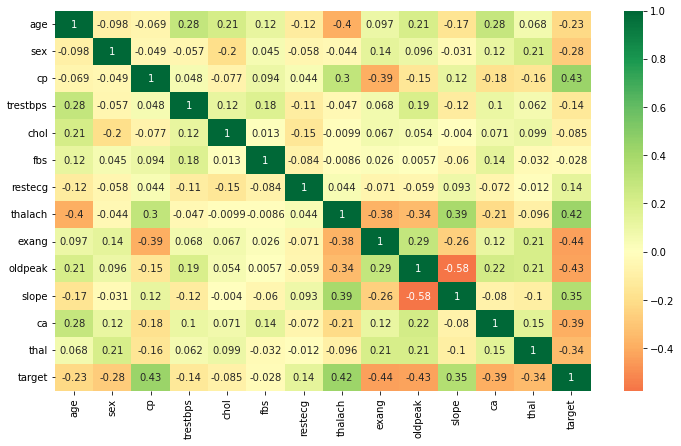

<Figure size 864x504 with 2 Axes>

In [ ]:
sns.heatmap(df.corr(), cmap="RdYlGn", annot = True, center=0)
fig = plt.gcf()
fig.set_size_inches(12,7)
plt.show()

Nothing significant enough

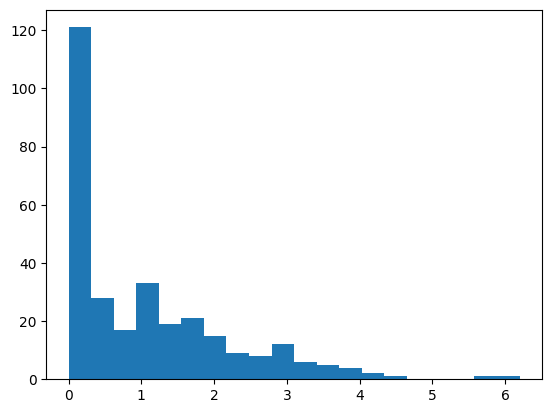

(array([121.,  28.,  17.,  33.,  19.,  21.,  15.,   9.,   8.,  12.,   6.,
          5.,   4.,   2.,   1.,   0.,   0.,   0.,   1.,   1.]),
 array([0.  , 0.31, 0.62, 0.93, 1.24, 1.55, 1.86, 2.17, 2.48, 2.79, 3.1 ,
        3.41, 3.72, 4.03, 4.34, 4.65, 4.96, 5.27, 5.58, 5.89, 6.2 ]),
 <BarContainer object of 20 artists>)

In [ ]:
plt.hist(df.oldpeak, bins = 20)

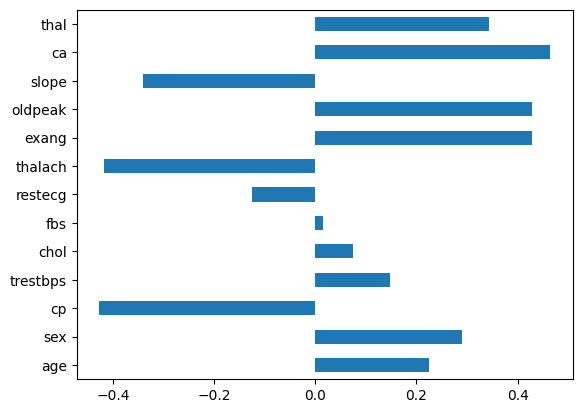

<AxesSubplot:>

In [ ]:
df[df['ca'] < 4].corr()['target'].drop('target').plot(kind='barh')

In [36]:
df['oldpeak'][df['oldpeak'] > 4].value_counts()

# Models and Testing
We will test a number of models, first without cross validation and then with it to see the effects of data leakage. The "best model" selection and subsequent sections will be done based on the cross validation results only.

In [37]:
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from random import randint
from sklearn.dummy import DummyClassifier

# The Models:

In [38]:
df=df[df['ca'] < 4]
df=df[df['thal'] > 0]

# Train/Test Split

**We have 296 examples - let's use 20% for test and the rest for train, then split to inputs and labels**

In [39]:
from sklearn.model_selection import train_test_split

x, y = df.drop('target', axis=1), df.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, shuffle=True)

In [40]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((236, 13), (236,), (60, 13), (60,))

# Benchmark

In [41]:
y_train.value_counts()

**Now we prepare a dummy score that we will use in the cross validation comparisons later:**

In [42]:
dummy_clf = DummyClassifier(strategy="most_frequent")
models = [dummy_clf]
scores = []
train_scores = []
model_name = []


**We'll now set a benchmark score: the most common label in the train set**

**As this is a classification problem that is pretty balanced in its labels, we can use accuracy as our evaluation metric**

In [43]:
def get_benchmark_predictions(x, benchmark_value):
    # returns a numpy array on the same length as x with all values equal to benchmark_value
    return np.ones(len(x))*benchmark_value

benchmk_val = 0

train_acc = accuracy_score(y_train, get_benchmark_predictions(x_train, benchmk_val))
test_acc = accuracy_score(y_test, get_benchmark_predictions(x_test, benchmk_val))

benchmark_scores = train_acc, test_acc
print(benchmark_scores)

train_scores.append(train_acc)
scores.append(test_acc)
model_name.append('Benchmark')

(0.559322033898305, 0.4666666666666667)


# KNN Non-scaled (3 different k's)

In [44]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=16)
clf.fit(x_train, y_train)
print("k=", clf.n_neighbors, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
knn1 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

clf = KNeighborsClassifier(n_neighbors=17)
clf.fit(x_train, y_train)
print("k=", clf.n_neighbors, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
knn2 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

clf = KNeighborsClassifier(n_neighbors=18)
clf.fit(x_train, y_train)
print("k=", clf.n_neighbors, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
knn3 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

k= 16 : Train: 0.6991525423728814 | Test: 0.7
k= 17 : Train: 0.6864406779661016 | Test: 0.7
k= 18 : Train: 0.7076271186440678 | Test: 0.6666666666666666


**Much better than the benchmark but we know that KNN can greatly suffer from features that are in different scales. So let's scale the x values:**

# KNN Scaled (3 different k's)

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

clf = KNeighborsClassifier(n_neighbors=16)
clf.fit(x_train_scaled, y_train)
print("k=", clf.n_neighbors, ":", "Train:", clf.score(x_train_scaled,y_train), "| Test:", clf.score(x_test_scaled,y_test))
knn1_scaled = clf
model_name.append(clf) #for cv

clf = KNeighborsClassifier(n_neighbors=17)
clf.fit(x_test_scaled, y_test)
print("k=", clf.n_neighbors, ":", "Train:", clf.score(x_train_scaled,y_train), "| Test:", clf.score(x_test_scaled,y_test))
knn2_scaled = clf
model_name.append(clf) #for cv

clf = KNeighborsClassifier(n_neighbors=18)
clf.fit(x_train_scaled, y_train)
print("k=", clf.n_neighbors, ":", "Train:", clf.score(x_train_scaled,y_train), "| Test:", clf.score(x_test_scaled,y_test))
knn3_scaled =  clf
model_name.append(clf) #for cv

k= 16 : Train: 0.847457627118644 | Test: 0.9
k= 17 : Train: 0.7966101694915254 | Test: 0.85
k= 18 : Train: 0.8177966101694916 | Test: 0.8833333333333333


**We can see KNN indeed improves after scaling**

# Decision Tree (3 different max depth)

In [46]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf = DecisionTreeClassifier(max_depth=3, random_state=0)
clf.fit(x_train, y_train)
print("k=", clf.max_depth, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
dt1 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

clf = DecisionTreeClassifier(max_depth=6, random_state=0)
clf.fit(x_train, y_train)
print("k=", clf.max_depth, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
dt2 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

clf = DecisionTreeClassifier(max_depth=9, random_state=0)
clf.fit(x_train, y_train)
print("k=", clf.max_depth, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
dt3 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

k= 3 : Train: 0.8601694915254238 | Test: 0.8166666666666667
k= 6 : Train: 0.923728813559322 | Test: 0.8166666666666667
k= 9 : Train: 0.9915254237288136 | Test: 0.7833333333333333


**We can see the decision trees performed a bit worse and k=9 has some overfitting**

# Here are some nice-looking trees: 

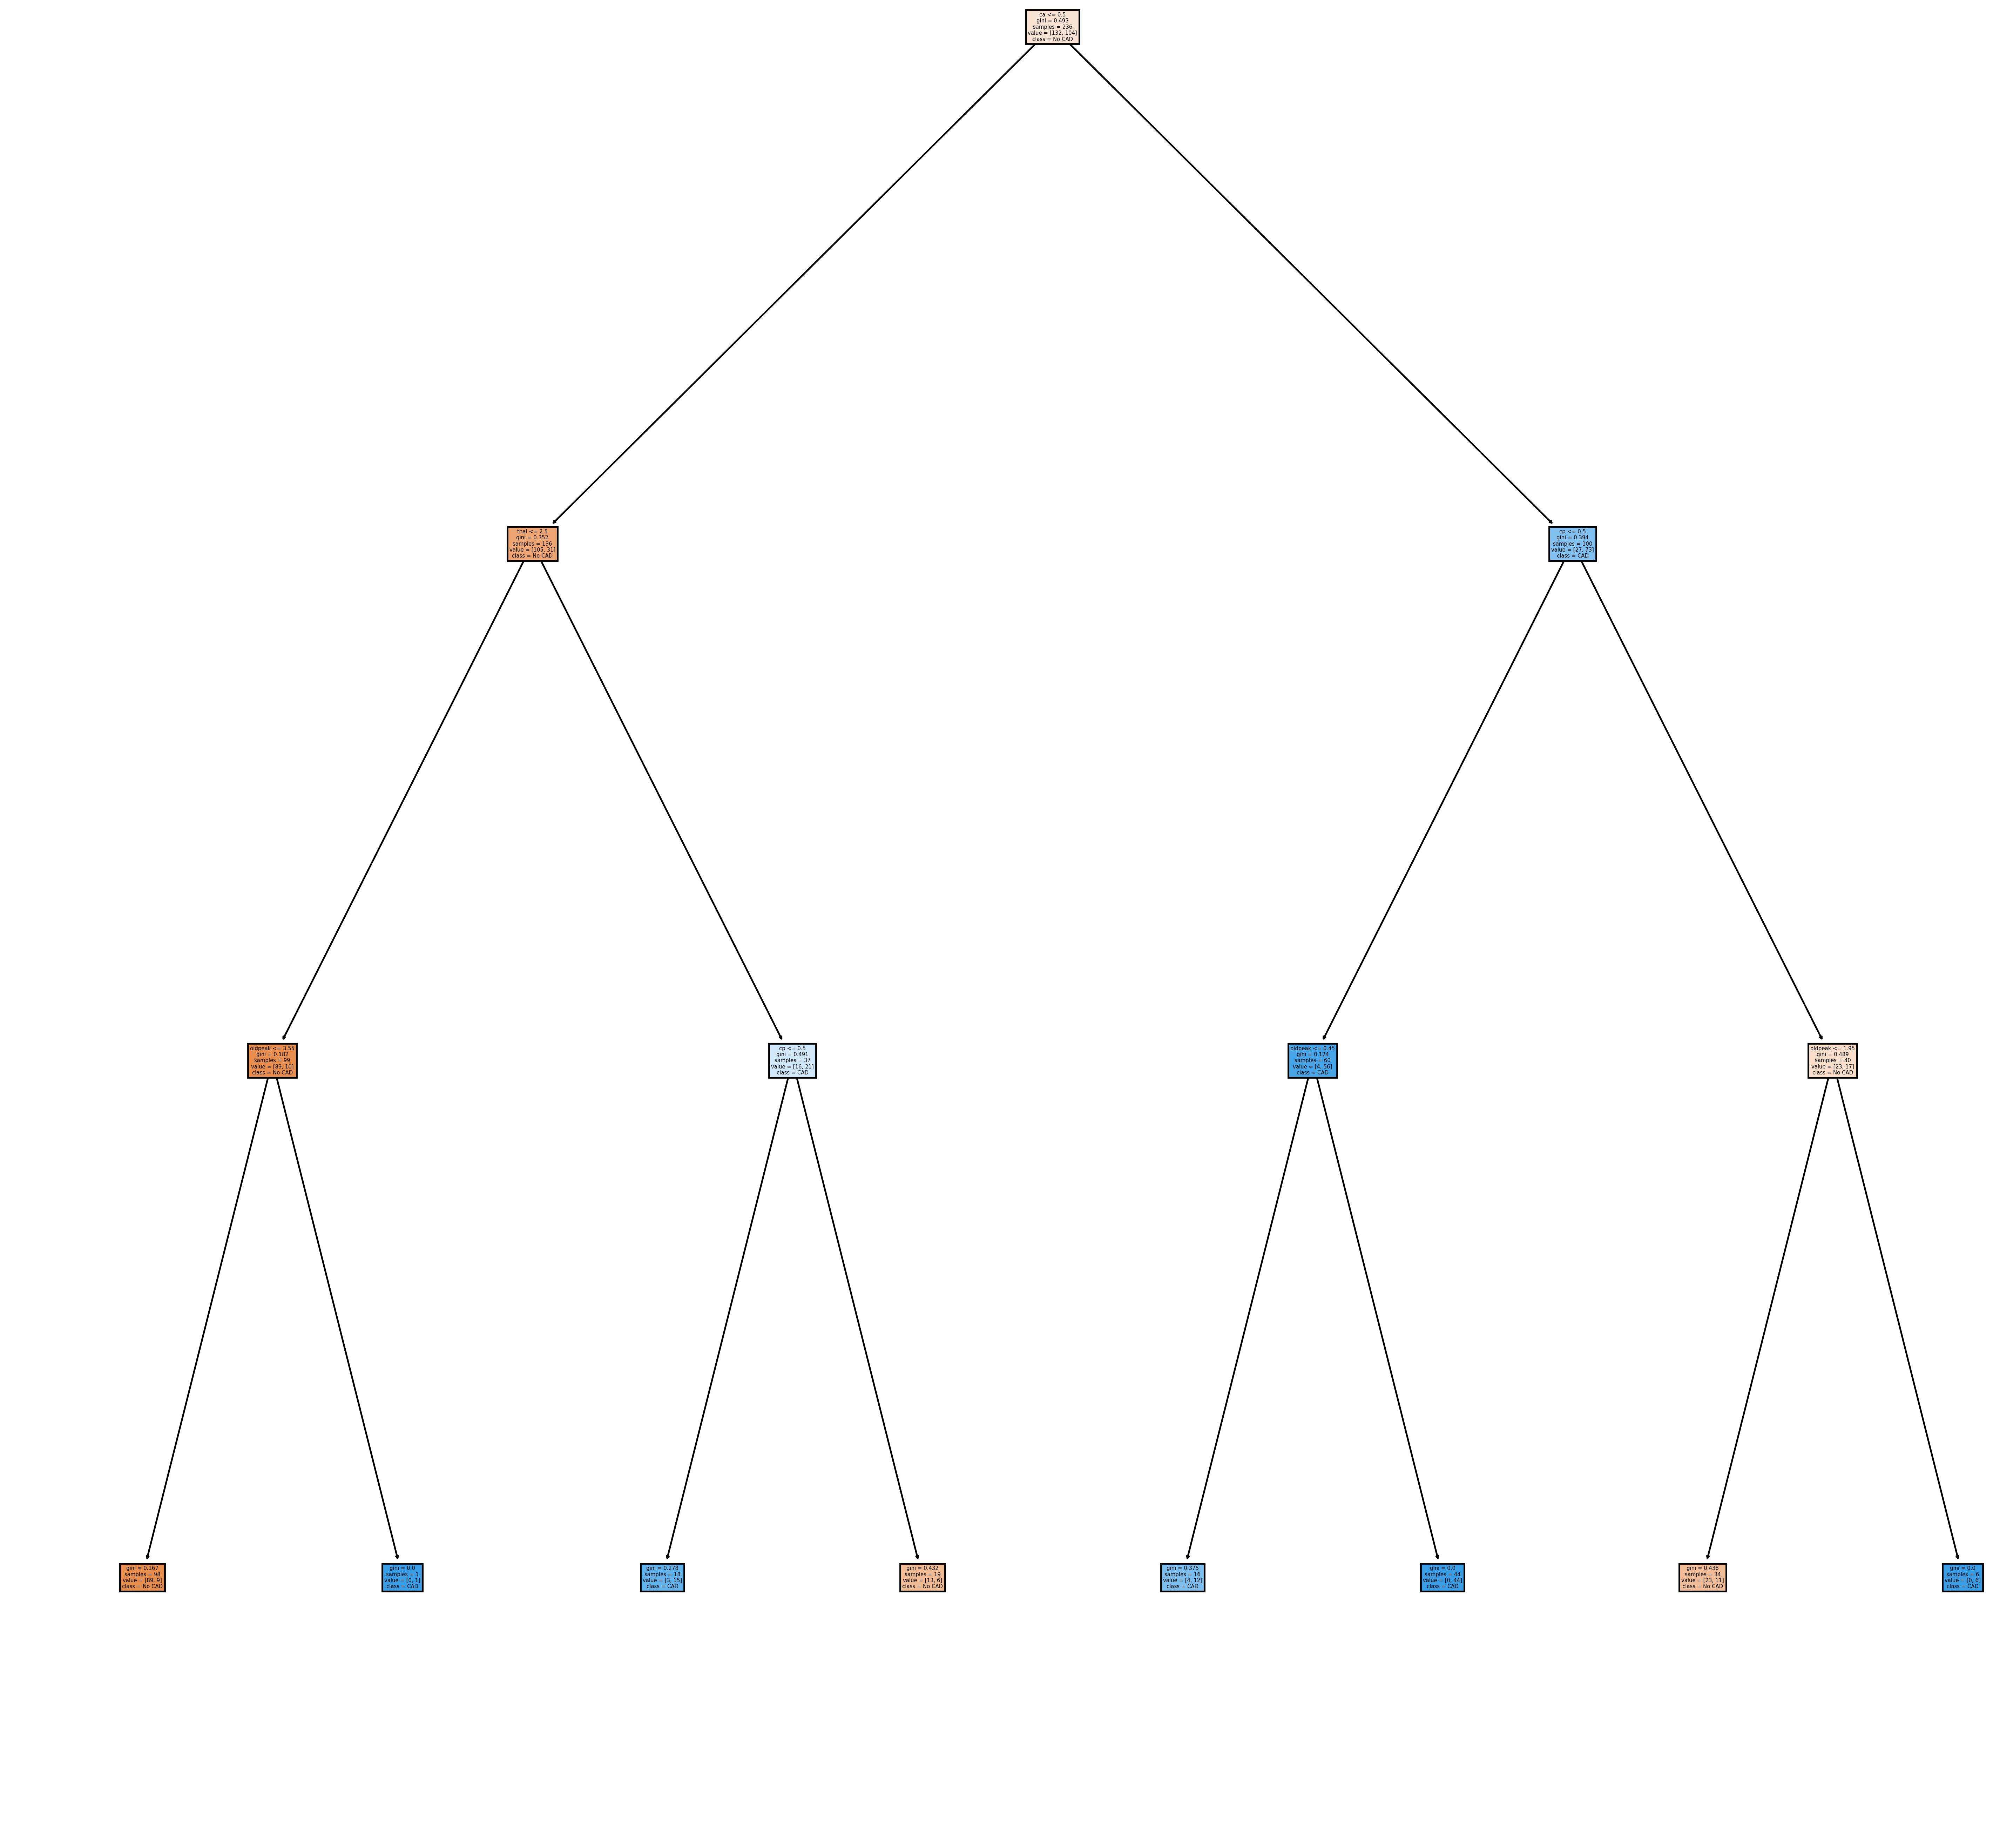

In [47]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4.5,4.5), dpi=350)
plot_tree(dt1,
           feature_names=x_train.columns,
           class_names=['No CAD', 'CAD'],
           filled = True);

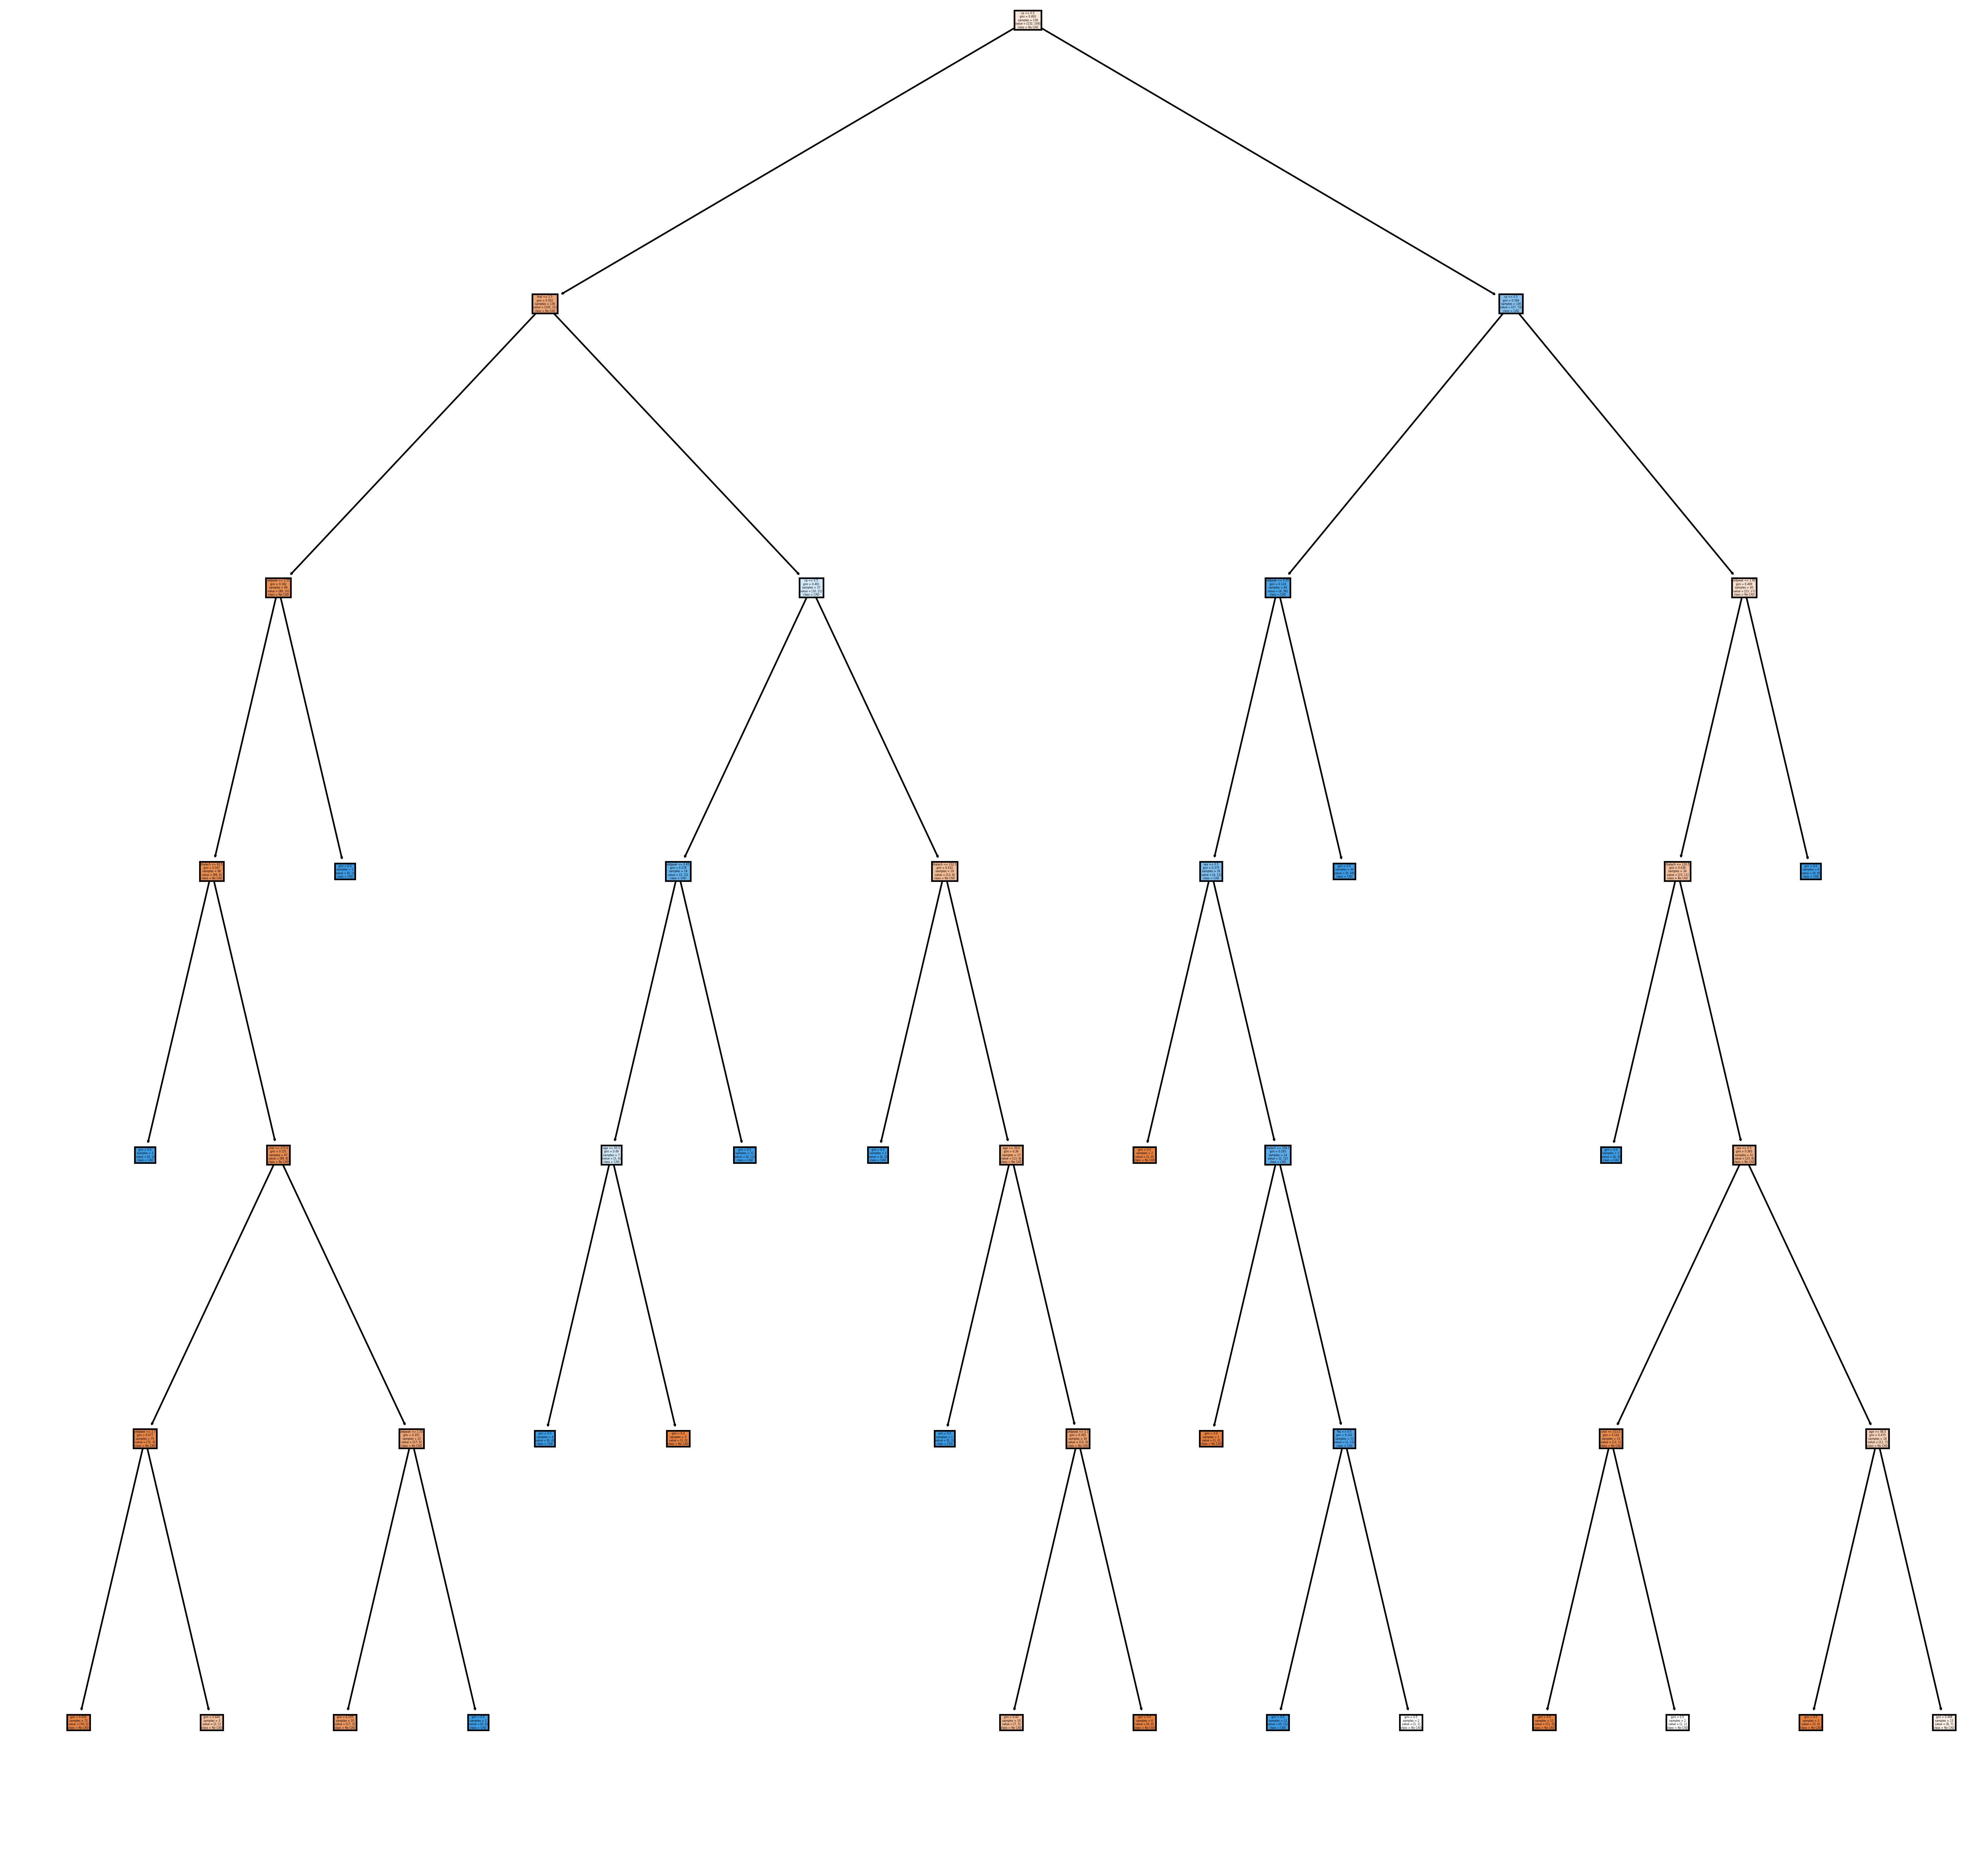

In [48]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4.5,4.5), dpi=350)
plot_tree(dt2,
           feature_names=x_train.columns,
           class_names=['No CAD', 'CAD'],
           filled = True);

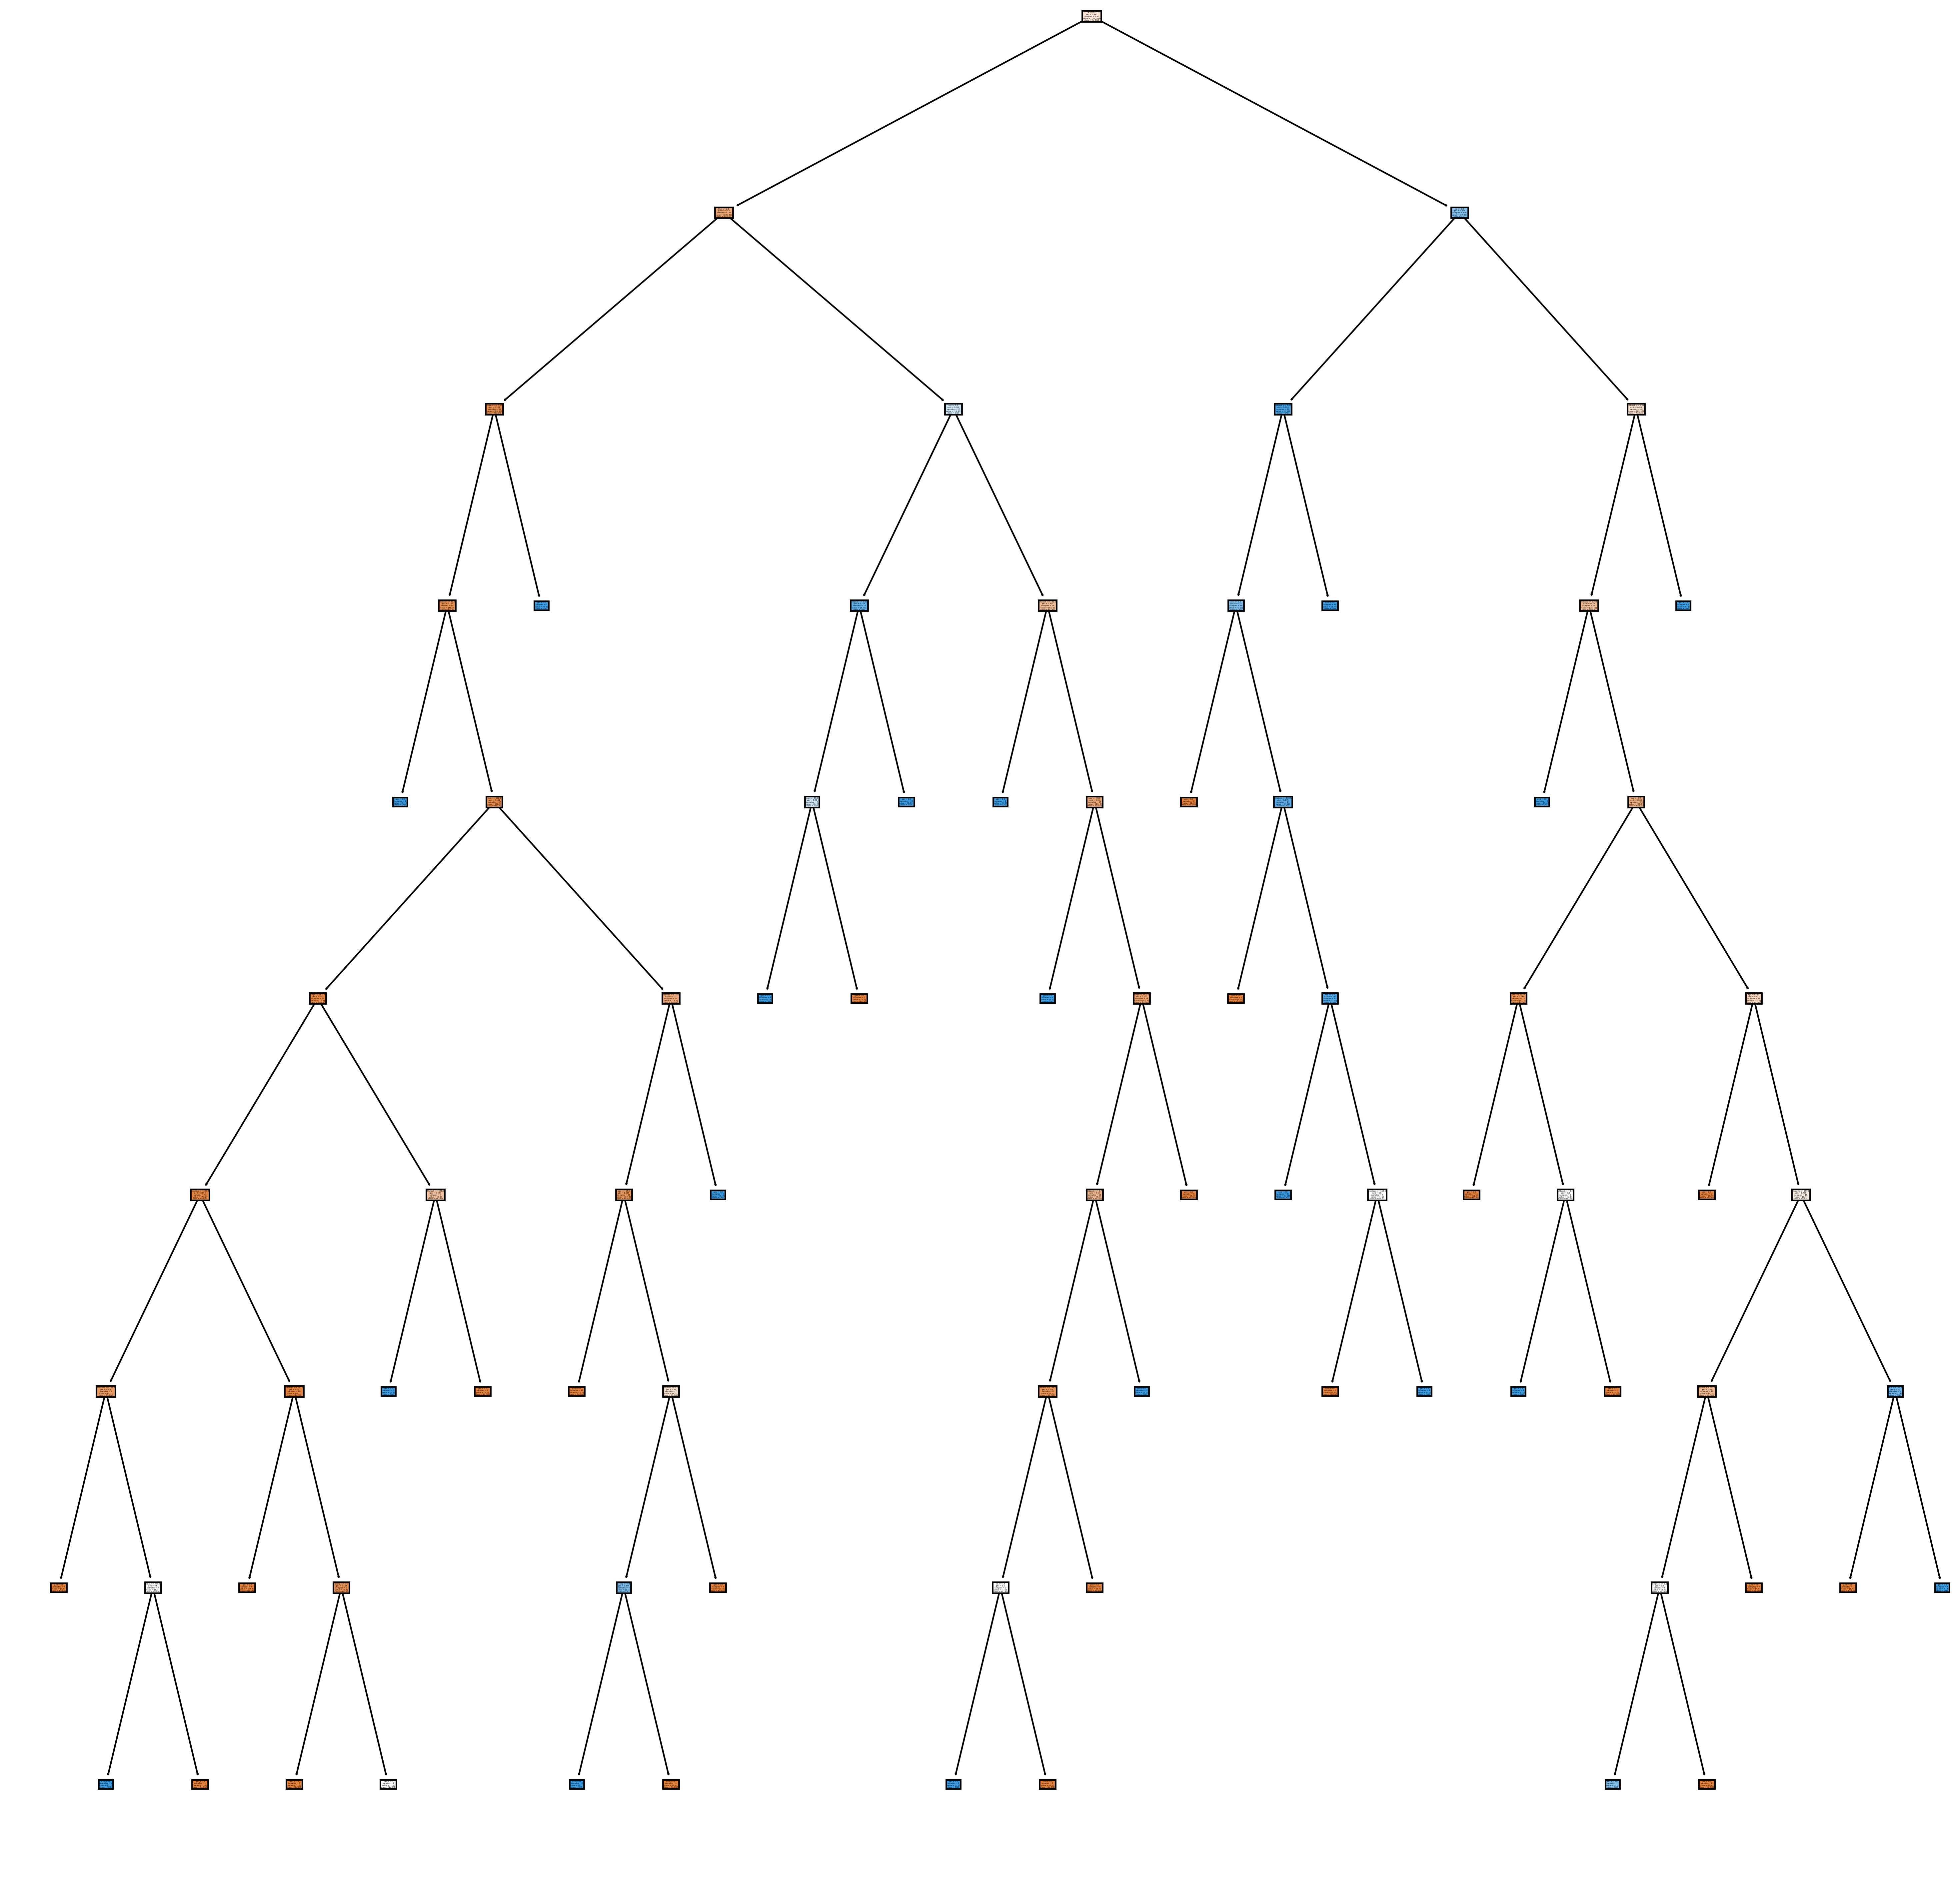

In [49]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4.5,4.5), dpi=350)
plot_tree(dt3,
           feature_names=x_train.columns,
           class_names=['No CAD', 'CAD'],
           filled = True);

# Random Forest (3 different max depth, n_estimators=100)

In [50]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=0)
clf.fit(x_train, y_train)
print("k=", clf.max_depth, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
rf1 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
clf.fit(x_train, y_train)
print("k=", clf.max_depth, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
rf2 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

clf = RandomForestClassifier(n_estimators=100, max_depth=9, random_state=0)
clf.fit(x_train, y_train)
print("k=", clf.max_depth, ":", "Train:", clf.score(x_train,y_train), "| Test:", clf.score(x_test,y_test))
rf3 = clf
models.append(clf) #for cv
scores.append(clf.score(x_test,y_test))
train_scores.append(clf.score(x_train,y_train))
model_name.append(clf) #for cv

k= 3 : Train: 0.8771186440677966 | Test: 0.8833333333333333
k= 6 : Train: 0.961864406779661 | Test: 0.8333333333333334
k= 9 : Train: 0.9957627118644068 | Test: 0.8


# Feature Importance of Random Forest

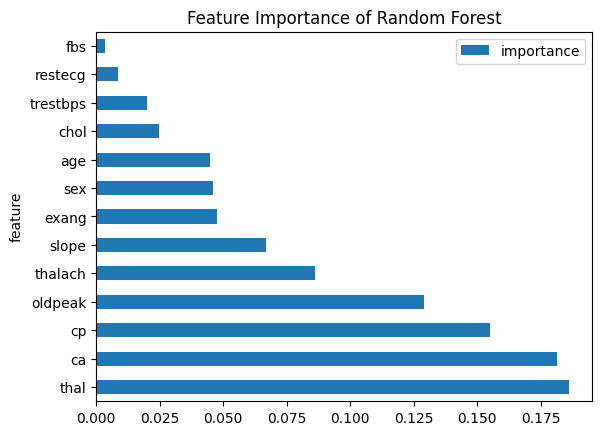

In [51]:
import matplotlib.pyplot as plt
feature_importances = rf1.feature_importances_
features = x_train.columns
stats = pd.DataFrame({'feature':features, 'importance':feature_importances})
top_13 = stats.sort_values('importance', ascending=False).head(13)
top_13.plot(y='importance', x='feature', kind='barh')
plt.title('Feature Importance of Random Forest');

**As we suspected, fbs is indeed the least important feature so, in hindsight, we probably could have removed it during preprocessing. Oh well. More importantly, it's good that we cleaned up the missing values from thal and ca because they were apparently the most important!**

# Ada Boost (n_estimators=100)

In [52]:
from sklearn.ensemble import AdaBoostClassifier
for i in range (3,10,3):
    base = DecisionTreeClassifier(max_depth=i)
    adaclf = AdaBoostClassifier(base_estimator = base, n_estimators=100, random_state=0)
    adaclf.fit(x_train, y_train)
    print("Max Depth =", i, ":", "Train:", adaclf.score(x_train,y_train), "| Test:", adaclf.score(x_test,y_test))
    models.append(adaclf)
    scores.append(adaclf.score(x_test,y_test))
    train_scores.append(adaclf.score(x_train,y_train))
    model_name.append(adaclf)

Max Depth = 3 : Train: 1.0 | Test: 0.85
Max Depth = 6 : Train: 1.0 | Test: 0.85
Max Depth = 9 : Train: 1.0 | Test: 0.75


# Cross Validation

**We now split 20% for validation - this set will stay untouched until the end**

In [53]:
x_training_data,x_validation_set,y_training_data, y_validation_set = train_test_split(x, y, test_size=0.2, random_state=0,)
x_training_data.shape, y_training_data.shape, x_validation_set.shape, y_validation_set.shape

((236, 13), (236,), (60, 13), (60,))

In [54]:
from sklearn.pipeline import Pipeline
#creating a pipeline for the cross validation so it rescales with each fold (only relevant for knn-scaled)

steps1 = list()
steps1.append(('scaler', StandardScaler()))
steps1.append(('model',knn1_scaled))
models.append(Pipeline(steps=steps1))
scores.append(knn1_scaled.score(x_test_scaled,y_test)) #saving the earlier scores for comparison
train_scores.append(knn1_scaled.score(x_train_scaled,y_train)) #saving the earlier scores for comparison

steps2 = list()
steps2.append(('scaler', StandardScaler()))
steps2.append(('model',knn2_scaled))
models.append(Pipeline(steps=steps2))
scores.append(knn2_scaled.score(x_test_scaled,y_test)) #saving the earlier scores for comparison
train_scores.append(clf.score(x_train_scaled,y_train)) #saving the earlier scores for comparison

steps3 = list()
steps3.append(('scaler', StandardScaler()))
steps3.append(('model',knn3_scaled))
models.append(Pipeline(steps=steps3))
scores.append(knn1_scaled.score(x_test_scaled,y_test)) #saving the earlier scores for comparison
train_scores.append(clf.score(x_train_scaled,y_train)) #saving the earlier scores for comparison

/opt/python/envs/default/lib/python3.8/site-packages/sklearn/base.py:445: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/python/envs/default/lib/python3.8/site-packages/sklearn/base.py:445: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [55]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=0)
cv_scores = []
for model in models: 
    n_scores = cross_val_score(model, x_training_data, y_training_data, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
    cv_scores.append(np.mean(n_scores))
    
    print(model, 'CV Score: %.3f' % np.mean(n_scores))
    

DummyClassifier(strategy='most_frequent') CV Score: 0.559
KNeighborsClassifier(n_neighbors=16) CV Score: 0.671
KNeighborsClassifier(n_neighbors=17) CV Score: 0.671
KNeighborsClassifier(n_neighbors=18) CV Score: 0.655
DecisionTreeClassifier(max_depth=3, random_state=0) CV Score: 0.789
DecisionTreeClassifier(max_depth=6, random_state=0) CV Score: 0.752
DecisionTreeClassifier(max_depth=9, random_state=0) CV Score: 0.727
RandomForestClassifier(max_depth=3, random_state=0) CV Score: 0.846
RandomForestClassifier(max_depth=6, random_state=0) CV Score: 0.839
RandomForestClassifier(max_depth=9, random_state=0) CV Score: 0.828
AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3),
                   n_estimators=100, random_state=0) CV Score: 0.740
AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=6),
                   n_estimators=100, random_state=0) CV Score: 0.783
AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=9),
                   n_est

In [56]:
model_names = [str(i) for i in models]

In [57]:
perf = ({'non-CV Train':train_scores, 'non-CV Test ': scores, 'Cross-validation': cv_scores})
perf_table = pd.DataFrame(data=perf,  index = model_names)
perf_table.sort_values(by = ['Cross-validation'] , ascending= False)

,non-CV Train,non-CV Test,Cross-validation
"RandomForestClassifier(max_depth=3, random_state=0)",0.877119,0.883333,0.845531
"RandomForestClassifier(max_depth=6, random_state=0)",0.961864,0.833333,0.838768
"RandomForestClassifier(max_depth=9, random_state=0)",0.995763,0.800000,0.827536
"Pipeline(steps=[('scaler', StandardScaler()),\n ('model', KNeighborsClassifier(n_neighbors=17))])",0.758475,0.850000,0.826027
"Pipeline(steps=[('scaler', StandardScaler()),\n ('model', KNeighborsClassifier(n_neighbors=16))])",0.847458,0.900000,0.820411
"Pipeline(steps=[('scaler', StandardScaler()),\n ('model', KNeighborsClassifier(n_neighbors=18))])",0.758475,0.900000,0.816184
"DecisionTreeClassifier(max_depth=3, random_state=0)",0.860169,0.816667,0.789372
"AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=6),\n n_estimators=100, random_state=0)",1.000000,0.850000,0.782609
"DecisionTreeClassifier(max_depth=6, random_state=0)",0.923729,0.816667,0.752476
"AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=9),\n n_estimators=100, random_state=0)",1.000000,0.750000,0.745833


**We will select the best performing algorithm based only on the cross validation scores so as to avoid data leakage / "lucky splits"**

**We can see that the best performing algorithm is the Random Forest with a Max Depth of 3**

# Hyperparameters

**Using the best algorithm we found, we'll use GridSearch to determine the hyperparameters that best improve the performance.**

In [58]:
from sklearn.model_selection import GridSearchCV

fit_rf = RandomForestClassifier(random_state=0)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=0)
param_dist = {'n_estimators': range(25, 150, 25),
                'max_depth': range(1,6),
                'criterion': ['gini', 'entropy']}

cv_rf = GridSearchCV(fit_rf, cv = cv,
                     param_grid=param_dist)

cv_rf.fit(x_training_data, y_training_data)

print('Best Parameters using grid search: \n', cv_rf.best_params_)

Best Parameters using grid search: 
 {'criterion': 'gini', 'max_depth': 3, 'n_estimators': 100}


In [59]:
best_model = cv_rf.best_estimator_
best_model

RandomForestClassifier(max_depth=3, random_state=0)

# Additional analysis 
We now check the performance of our selected best algorithm with varying amounts of data: [10%/30%/50%/70%/100%] of the train set for training the algorithm

In [60]:
values = [0.1, 0.3, 0.5, 0.7]
amount_vs_score = []

for i in values:
    x_train_adalysis,x_non_train_adalysis, y_train_adalysis, y_non_train_adalysis  = train_test_split(x_training_data,y_training_data, random_state=0, train_size=i)
    best_model.fit(x_train_adalysis, y_train_adalysis)
    print('Accuracy using ',i , ' of the training:')
    print(best_model.score(x_validation_set, y_validation_set))
    amount_vs_score.append(best_model.score(x_validation_set, y_validation_set))
                           
best_model.fit(x_training_data,y_training_data)
values.append(1)
print('Accuracy using ',1 , ' of the training:')
print(best_model.score(x_validation_set, y_validation_set))
amount_vs_score.append(best_model.score(x_validation_set, y_validation_set))

Accuracy using  0.1  of the training:
0.7
Accuracy using  0.3  of the training:
0.85
Accuracy using  0.5  of the training:
0.8833333333333333
Accuracy using  0.7  of the training:
0.8666666666666667
Accuracy using  1  of the training:
0.8833333333333333


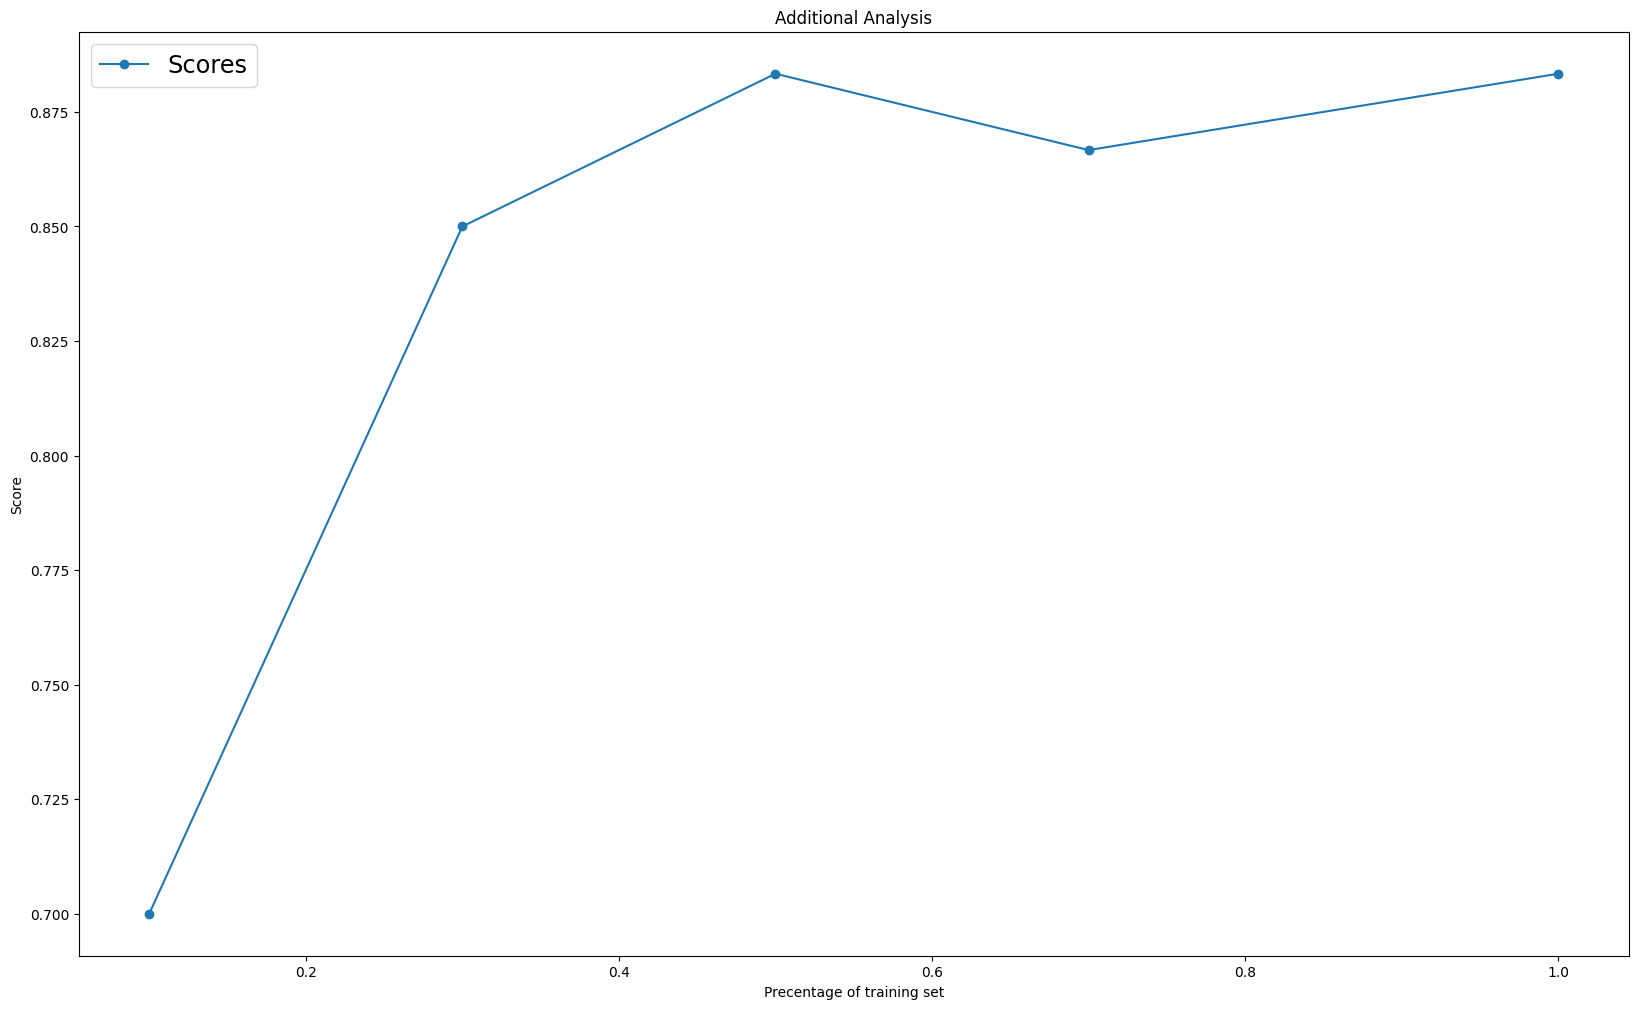

In [61]:
fig, ax = plt.subplots(1, figsize=(20,12))
ax.plot([0.1,0.3,0.5,0.7,1], amount_vs_score, marker='o', label='Scores')
ax.set_xlabel("Precentage of training set")
ax.set_ylabel('Score')
ax.title.set_text("Additional Analysis")
ax.legend(fontsize='xx-large')
plt.show()

**Having run the algorithm on our validation set, we see that the best score of 0.88333 is achieved by using either .5 of the data or all of the data. We recommend using all the data.**

**Just to double-check, since this is a medical problem we're dealing with, let's see what the confusion matrix (using all the data) looks like:**

/opt/python/envs/default/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


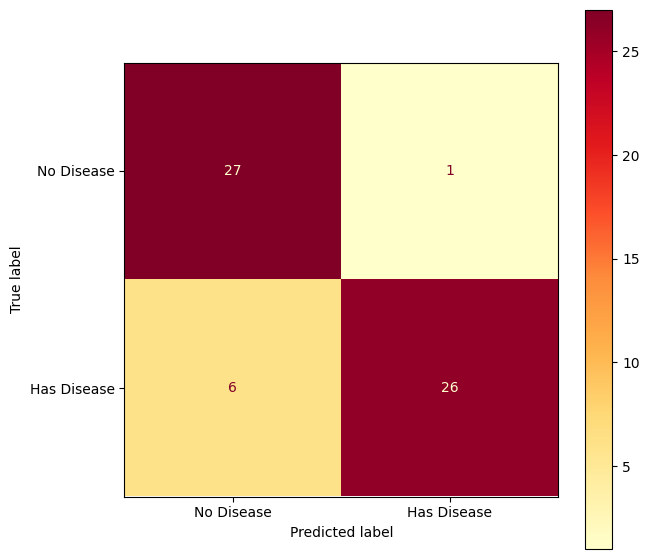

In [62]:
from sklearn.metrics import plot_confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
plot_confusion_matrix(best_model, x_validation_set, y_validation_set, values_format = '', 
                      display_labels=['No Disease', 'Has Disease'], cmap='YlOrRd')
fig = plt.gcf()
fig.set_size_inches(7, 7)
plt.show()

**Pretty good!**